In [2]:
!pip install albumentations==1.4.4



   ---------------------------------------- 0.0/38.9 MB ? eta -:--:--
   - -------------------------------------- 1.0/38.9 MB 6.7 MB/s eta 0:00:06
   - -------------------------------------- 1.8/38.9 MB 5.1 MB/s eta 0:00:08
   -- ------------------------------------- 2.6/38.9 MB 4.6 MB/s eta 0:00:08
   --- ------------------------------------ 3.4/38.9 MB 4.4 MB/s eta 0:00:09
   ---- ----------------------------------- 4.2/38.9 MB 4.3 MB/s eta 0:00:09
   ----- ---------------------------------- 5.0/38.9 MB 4.2 MB/s eta 0:00:09
   ----- ---------------------------------- 5.8/38.9 MB 4.2 MB/s eta 0:00:08
   ------- -------------------------------- 6.8/38.9 MB 4.1 MB/s eta 0:00:08
   ------- -------------------------------- 7.6/38.9 MB 4.1 MB/s eta 0:00:08
   -------- ------------------------------- 8.4/38.9 MB 4.1 MB/s eta 0:00:08
   --------- ------------------------------ 9.2/38.9 MB 4.1 MB/s eta 0:00:08
   ---------- ----------------------------- 10.0/38.9 MB 4.0 MB/s eta 0:00:08
   --


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


loading annotations into memory...
Done (t=1.11s)
creating index...
index created!


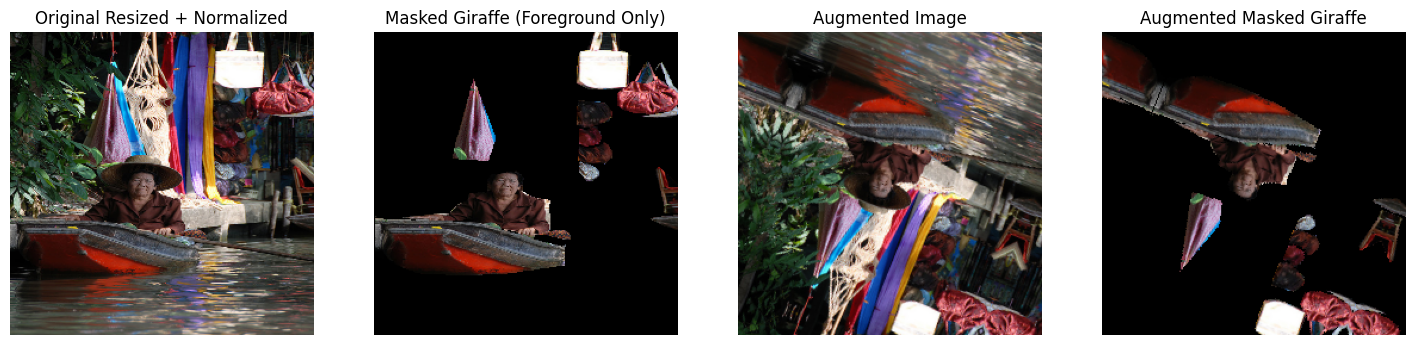

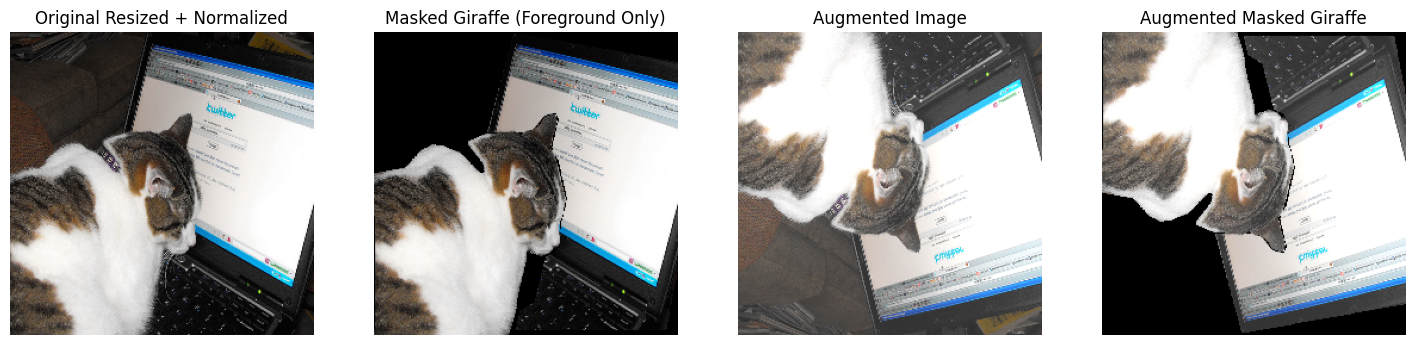

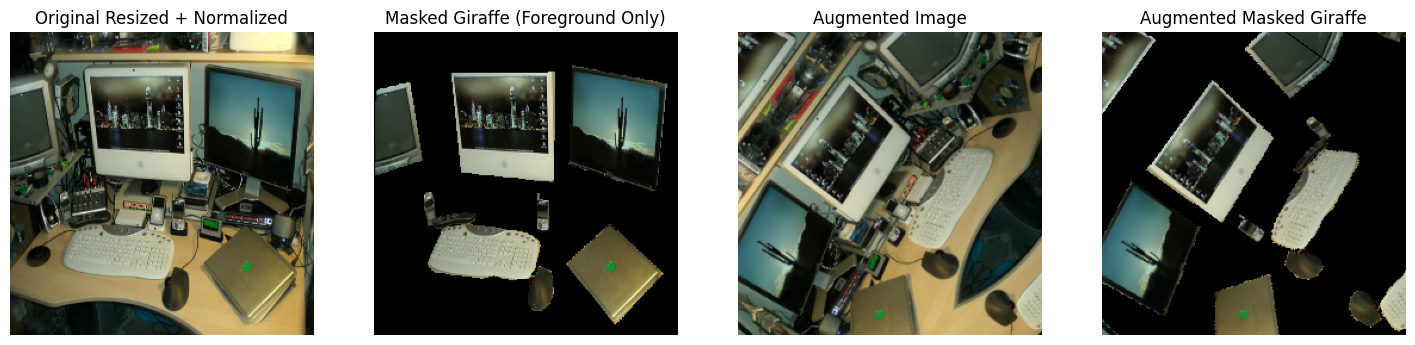

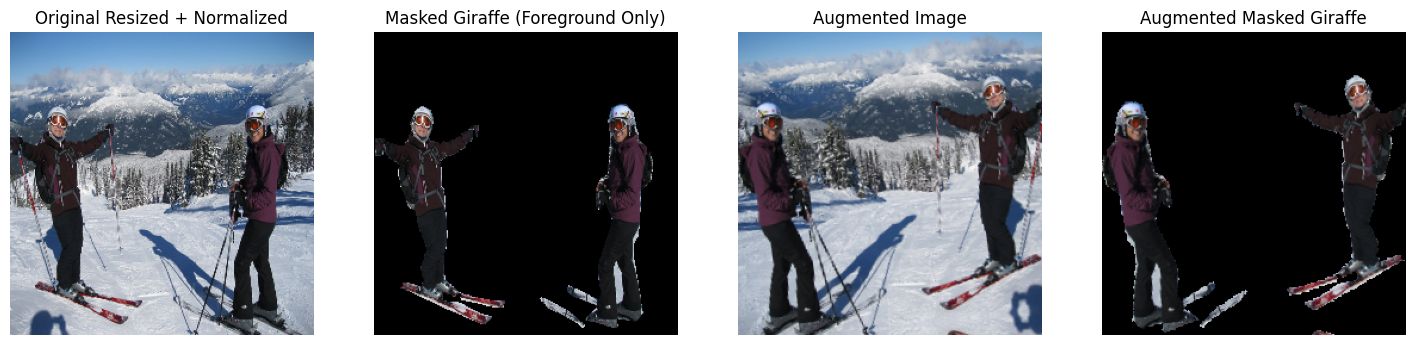

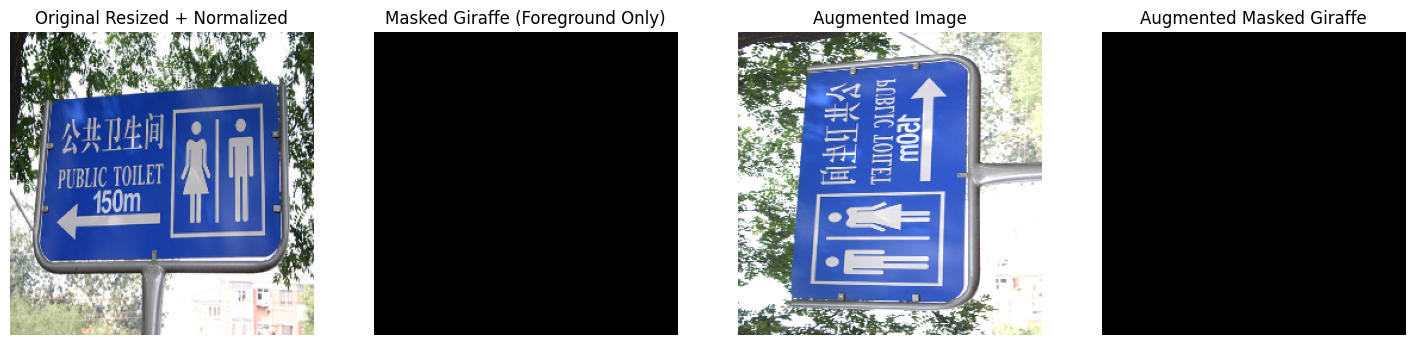

In [4]:
import os, random, numpy as np, matplotlib.pyplot as plt, cv2
from pycocotools.coco import COCO
import albumentations as A

# Paths (update if needed)
imgDir  = r"C:\Users\KIIT0001\Desktop\infosys aiml\val2017\val2017"
annFile = r"C:\Users\KIIT0001\Desktop\infosys aiml\annotations_trainval2017\annotations\instances_val2017.json"

# Load COCO
coco = COCO(annFile)

# Get all image IDs
imgIds = coco.getImgIds()
random.shuffle(imgIds)

# Select 5 random images
sample_imgIds = imgIds[:5]

# Define augmentation pipeline
transform = A.Compose([
    A.Resize(255, 255),
    A.RandomRotate90(),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=45, p=0.7),
    A.RandomBrightnessContrast(p=0.5)
])

for idx, imgId in enumerate(sample_imgIds, 1):
    imgInfo = coco.loadImgs(imgId)[0]

    # Load image
    imgPath = os.path.join(imgDir, imgInfo['file_name'])
    image = cv2.cvtColor(cv2.imread(imgPath), cv2.COLOR_BGR2RGB)

    # Load annotations
    annIds = coco.getAnnIds(imgIds=imgInfo['id'])
    anns = coco.loadAnns(annIds)

    # Build combined mask
    mask = np.zeros((imgInfo['height'], imgInfo['width']), dtype=np.uint8)
    for ann in anns:
        mask |= coco.annToMask(ann).astype(np.uint8)

    # Apply augmentation to both image + mask
    augmented = transform(image=image, mask=mask)
    aug_img, aug_mask = augmented["image"], augmented["mask"]

    # Normalize
    image_norm = image.astype(np.float32) / 255.0
    aug_img_norm = aug_img.astype(np.float32) / 255.0

    # Resize + normalize original
    image_resized = cv2.resize(image, (255, 255)).astype(np.float32) / 255.0
    mask_resized = cv2.resize(mask, (255, 255), interpolation=cv2.INTER_NEAREST)

    # ✅ Create masked versions (foreground only, background = black)
    masked_image = image_resized.copy()
    masked_image[mask_resized == 0] = 0

    aug_masked_image = aug_img_norm.copy()
    aug_masked_image[aug_mask == 0] = 0

    # Display results
    fig, ax = plt.subplots(1, 4, figsize=(18, 6))
    ax[0].imshow(image_resized)
    ax[0].set_title("Original Resized + Normalized")
    ax[0].axis("off")

    ax[1].imshow(masked_image)
    ax[1].set_title("Masked Giraffe (Foreground Only)")
    ax[1].axis("off")

    ax[2].imshow(aug_img_norm)
    ax[2].set_title("Augmented Image")
    ax[2].axis("off")

    ax[3].imshow(aug_masked_image)
    ax[3].set_title("Augmented Masked Giraffe")
    ax[3].axis("off")

    plt.show()


